<a href="https://colab.research.google.com/github/Developer-Abnam/100-Days-Of-ML-Code/blob/master/multi_layer_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Modules and Loading Dataset**

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Loading and Normalizing Image Data**

In [2]:
gray_scale = 255

x_train = x_train.astype('float32') / gray_scale
x_test = x_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", x_test.shape)
print("Target matrix (y_test):", y_test.shape)

Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


**Visualizing Data**

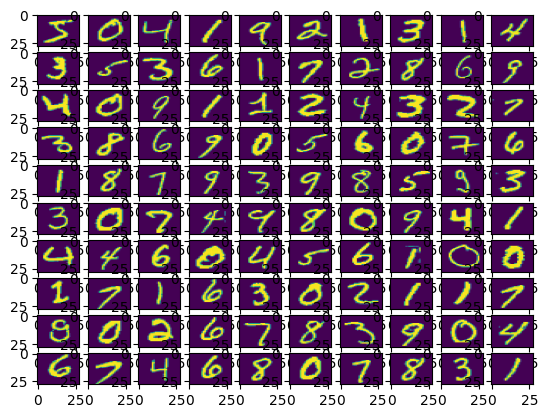

In [4]:
from enum import auto
fig, ax = plt.subplots(10,10)
k = 0
for i in range(10):
  for j in range(10):
    ax[i][j].imshow(x_train[k].reshape(28,28), aspect='auto')
    k +=1
plt.show()

**Building the Neural Network Model**

In [5]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Compiling the Model**

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

**Training the Model**

In [7]:
mod = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=2000,
    validation_split=0.2
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.3989 - loss: 2.1109 - val_accuracy: 0.7147 - val_loss: 1.7796
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7130 - loss: 1.4499 - val_accuracy: 0.7900 - val_loss: 1.0909
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.8071 - loss: 0.9083 - val_accuracy: 0.8512 - val_loss: 0.7050
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.8571 - loss: 0.6351 - val_accuracy: 0.8806 - val_loss: 0.5193
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8814 - loss: 0.4950 - val_accuracy: 0.8992 - val_loss: 0.4217
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8953 - loss: 0.4151 - val_accuracy: 0.9060 - val_loss: 0.3646
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9043 - loss: 0.3654 - val_accuracy: 0.9126 - val_loss: 0.3268
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9112 - loss: 0.3312 - val_accuracy: 0.9183 - 

**Evaluating the Model**

In [8]:
results = model.evaluate(x_test, y_test)
print("Test Loss, Test Accuracy", results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9241 - loss: 0.2724
Test Loss, Test Accuracy [0.27243873476982117, 0.9240999817848206]


**Visualizing of Data**

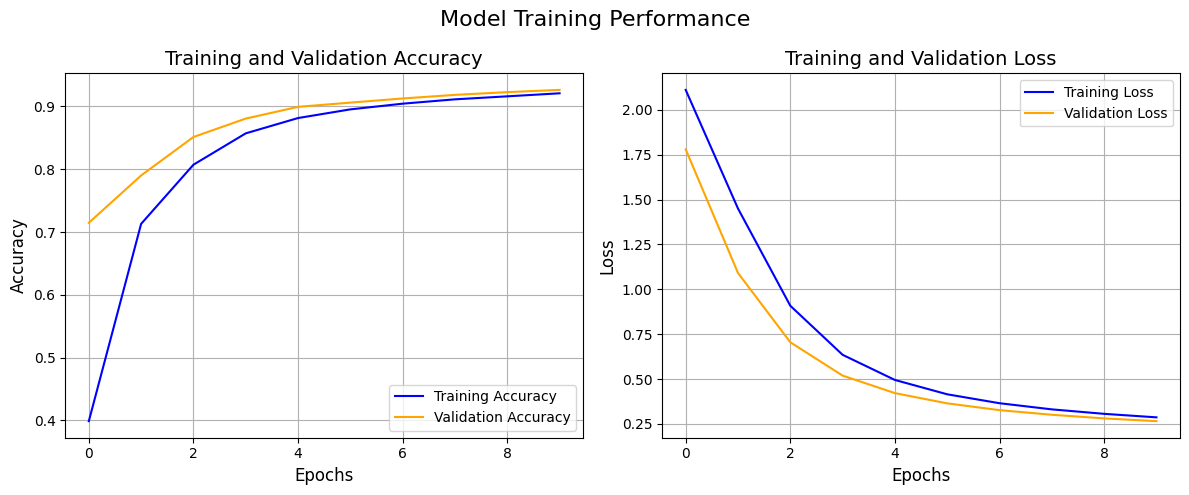

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()